# PTI-Clima Notebooks

> Este cuaderno o notebook ilustra el uso de los conjuntos de datos de la PTI-Clima que se incluyen en el [almacén de datos](https://pti.climate.ifca.es/data). Este trabajo está licenciado bajo una [Licencia Creative Commons Atribución 4.0 Internacional](http://creativecommons.org/licenses/by/4.0).

## Guía para el uso del dataset: PTI-grid (Iberia y Canarias)

**Ezequiel Cimadevilla** (Instituto de Física de Cantabria, CSIC-Universidad de Cantabria, Santander, Spain).

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

El almacén contiene distintas versiones de la rejilla PTI, las cuales pueden ser localizadas utilizando el inventario de datos.

In [2]:
domain = "Iberia" # or "Canarias"

df = pd.read_csv("../../data_inventory.csv")
pti_grid = df[(df["dataset"].str.contains("PTI-grid-v")) & (df["dataset"].str.contains(domain))]
pti_grid

,dataset,type,access,source,provider,experiment,frequency,endpoint,dictionary
4,PTI-grid-v0_Iberia_day,observations,opendap,PTI-grid-v0,NaN,NaN,day,https://hub.climate4r.ifca.es/thredds/dodsC/pt...,../../Harmonization_dictionaries/PTI-grid-v0.dic
6,PTI-grid-v1_Iberia_day,observations,opendap,PTI-grid-v1,NaN,NaN,day,https://hub.climate4r.ifca.es/thredds/dodsC/pt...,../../Harmonization_dictionaries/PTI-grid-v1.dic
8,PTI-grid-v2_Iberia_day,observations,opendap,PTI-grid-v2,NaN,NaN,day,https://hub.climate4r.ifca.es/thredds/dodsC/pt...,../../Harmonization_dictionaries/PTI-grid-v1.dic


Cargamos las versiones `v2` y `v1` de las rejillas, creando un dataset de xarray que de acceso a toda la información.

In [3]:
pti_grid_v2 = xr.open_dataset(pti_grid["endpoint"].iloc[2]).chunk({"time": 45})
pti_grid_v1 = xr.open_dataset(pti_grid["endpoint"].iloc[1]).chunk({"time": 45})
# pti_grid_v0 = xr.open_dataset(pti_grid["endpoint"].iloc[0]).chunk({"time": 90}).rename({"lon": "longitude", "lat": "latitude"})

ds = xr.concat(
    [pti_grid_v2, pti_grid_v1],
    dim=xr.Variable("grid", ["PTI-grid-v2", "PTI-grid-v1"]),
    coords="minimal")

ds

<xarray.Dataset> Size: 244GB
Dimensions:    (grid: 2, time: 23376, latitude: 342, longitude: 545)
Coordinates:
  * latitude   (latitude) float64 3kB 35.29 35.31 35.34 ... 43.76 43.79 43.81
  * longitude  (longitude) float64 4kB -9.287 -9.262 -9.238 ... 4.287 4.312
  * time       (time) datetime64[ns] 187kB 1961-01-01 1961-01-02 ... 2024-12-31
  * grid       (grid) <U11 88B 'PTI-grid-v2' 'PTI-grid-v1'
Data variables:
    crs        (grid) |S64 128B b'' b''
    hurs       (grid, time, latitude, longitude) float32 35GB dask.array<chunksize=(1, 44, 342, 545), meta=np.ndarray>
    pr         (grid, time, latitude, longitude) float32 35GB dask.array<chunksize=(1, 44, 342, 545), meta=np.ndarray>
    ssrd       (grid, time, latitude, longitude) float32 35GB dask.array<chunksize=(1, 45, 342, 545), meta=np.ndarray>
    tasmax     (grid, time, latitude, longitude) float32 35GB dask.array<chunksize=(1, 44, 342, 545), meta=np.ndarray>
    tasmin     (grid, time, latitude, longitude) float32 35GB dask.array<chunksize=(1, 44, 342, 545), meta=np.ndarray>
    wss        (grid, time, latitude, longitude) float32 35GB dask.array<chunksize=(1, 44, 342, 545), meta=np.ndarray>
    tdps       (grid, time, latitude, longitude) float32 35GB dask.array<chunksize=(1, 44, 342, 545), meta=np.ndarray>
Attributes:
    conventions:                     CF-1.5
    version:                         1.0
    id:                              /genoma.lcsc/nfs/lcsc/griddingV3/hr_pen.nc
    institution:                     Consejo Superior de Investigaciones Cien...
    contact:                         https://lcsc.csic.es
    creation_date:                   Wed Oct  8 03:31:57 2025
    NCO:                             netCDF Operators version 5.3.6 (Homepage...
    history:                         Thu Jan  8 12:22:28 2026: ncrename -v hr...
    variable_id:                     tasmax
    DODS.strlen:                     0
    DODS_EXTRA.Unlimited_Dimension:  time

A modo de ilustración, creamos un gráfico con el primer paso de tiempo para cada version de la rejilla, para las variables `tasmin` y `tasmax`.

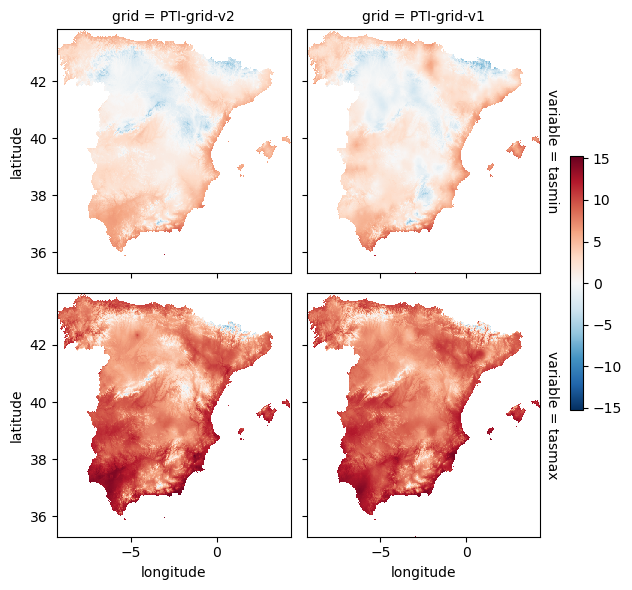

In [4]:
ds[["tasmin", "tasmax"]].isel(time=0).to_array("variable").plot(col="grid", row="variable", cbar_kwargs={"shrink": .5})

Calculamos la climatología para `tasmin` y `tasmax` que corresponde al período de verano para los años de 1991 a 2020, ambos incluidos.

In [5]:
subset_1991_2020 = ds.sel(time=ds["time"].dt.season == "JJA").sel(time=slice("19910101", "20201231"))[["tasmin", "tasmax"]]
subset_1991_2020

<xarray.Dataset> Size: 8GB
Dimensions:    (grid: 2, time: 2760, latitude: 342, longitude: 545)
Coordinates:
  * latitude   (latitude) float64 3kB 35.29 35.31 35.34 ... 43.76 43.79 43.81
  * longitude  (longitude) float64 4kB -9.287 -9.262 -9.238 ... 4.287 4.312
  * time       (time) datetime64[ns] 22kB 1991-06-01 1991-06-02 ... 2020-08-31
  * grid       (grid) <U11 88B 'PTI-grid-v2' 'PTI-grid-v1'
Data variables:
    tasmin     (grid, time, latitude, longitude) float32 4GB dask.array<chunksize=(1, 12, 342, 545), meta=np.ndarray>
    tasmax     (grid, time, latitude, longitude) float32 4GB dask.array<chunksize=(1, 12, 342, 545), meta=np.ndarray>
Attributes:
    conventions:                     CF-1.5
    version:                         1.0
    id:                              /genoma.lcsc/nfs/lcsc/griddingV3/hr_pen.nc
    institution:                     Consejo Superior de Investigaciones Cien...
    contact:                         https://lcsc.csic.es
    creation_date:                   Wed Oct  8 03:31:57 2025
    NCO:                             netCDF Operators version 5.3.6 (Homepage...
    history:                         Thu Jan  8 12:22:28 2026: ncrename -v hr...
    variable_id:                     tasmax
    DODS.strlen:                     0
    DODS_EXTRA.Unlimited_Dimension:  time

In [6]:
%time clim = subset_1991_2020.mean("time").compute(num_workers=4, scheduler="processes")

CPU times: user 2min 14s, sys: 4min 2s, total: 6min 16s
Wall time: 8min 20s


Dibujamos las climatologías correspondientes a los meses de verano del período 1991-2020.

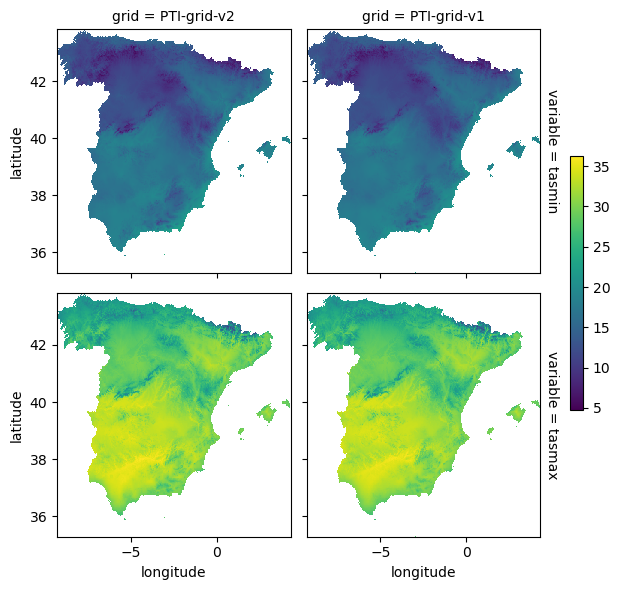

In [7]:
clim.to_array("variable").plot(col="grid", row="variable", cbar_kwargs={"shrink": .5},)